# Random Forest: Tuning & Feature Selection Experiments

## Objective
Optimize the Random Forest classifier through targeted feature validation and hyperparameter tuning. RF serves as the high-end benchmark model for this project - its ability to capture nonlinear feature interactions makes it the ceiling against which LR and CBA are compared.

## Experiment Plan
1. **Feature Validation:** Remove Accident Type and measure the impact on RF specifically
2. **Feature Importance Redistribution:** Examine how Gini importance shifts across remaining features without the dominant variable
3. **GridSearchCV:** Optimize tree-based hyperparameters on the locked 5-feature set
4. **Save best model** for final evaluation

## Why Fewer Experiments Than LR
The LR tuning notebook (Experiments 1-6) established feature selection decisions through empirical testing:
- **Track Type over Signalization:** 0.409 vs 0.378 F1 in LR. This is a feature-level finding, not model-specific.
- **RUCC_Metro_Adjacency over RUCC_2023:** Identical performance (0.4091 vs 0.4092), selected for interpretability.

These decisions carry forward from Phase 2 statistical analysis (Cramer's V, chi-square, Pearson correlation with Bonferroni correction) and LR empirical confirmation. Repeating them on RF would test the features, not the model. The one feature experiment worth running on RF is Accident Type removal, because the magnitude of the performance drop depends on the algorithm's ability to compensate through nonlinear splits.

## Methodology
- All experiments use 5-fold Stratified CV on the 80% training set
- Primary metric: Weighted F1-score
- Each experiment saves results to JSON in `../results/rf/`
- Random seed 521 throughout

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']
CAUSE_LABELS = {
    'E': 'Environmental', 'H': 'Human Factor',
    'M': 'Mechanical', 'S': 'Signal', 'T': 'Track'
}

## Helper Functions

Reusable functions for building pipelines, running CV, saving results, and comparing experiments. RF uses OrdinalEncoder instead of OneHotEncoder because decision trees split on thresholds (feature > X), so they naturally handle ordinal-encoded categories without needing binary columns. This keeps the feature space compact and avoids fragmenting split decisions across many dummy variables.

In [2]:
def build_rf_pipeline(categorical_features, numeric_features, **rf_kwargs):
    """
    Build a sklearn Pipeline: OrdinalEncoder -> RandomForestClassifier.
    
    No StandardScaler needed - trees are scale-invariant. They split on
    rank order, not magnitude, so scaling has no effect on performance.
    
    Parameters
    ----------
    categorical_features : list of str
        Columns to ordinal encode.
    numeric_features : list of str
        Columns to pass through directly.
    **rf_kwargs : dict
        Additional keyword arguments passed to RandomForestClassifier.
    
    Returns
    -------
    Pipeline
    """
    rf_params = {
        'n_estimators': 100,
        'random_state': RANDOM_SEED,
        'n_jobs': -1
    }
    rf_params.update(rf_kwargs)
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', 
                                    unknown_value=-1), 
             categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(**rf_params))
    ])
    
    return pipeline


def run_cv_experiment(pipeline, X, y, n_splits=5):
    """
    Run stratified k-fold CV and return per-fold scores and detailed metrics.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    scores = []
    last_y_val = None
    last_y_pred = None
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='weighted')
        scores.append(f1)
        
        last_y_val = y_val
        last_y_pred = y_pred
    
    precision_per_class = precision_score(last_y_val, last_y_pred, average=None,
                                          labels=CAUSE_ORDER, zero_division=0)
    recall_per_class = recall_score(last_y_val, last_y_pred, average=None,
                                    labels=CAUSE_ORDER, zero_division=0)
    f1_per_class = f1_score(last_y_val, last_y_pred, average=None,
                            labels=CAUSE_ORDER, zero_division=0)
    
    per_class = pd.DataFrame({
        'Cause': CAUSE_ORDER,
        'Precision': precision_per_class.round(3),
        'Recall': recall_per_class.round(3),
        'F1': f1_per_class.round(3)
    })
    
    return {
        'scores': [float(s) for s in scores],
        'mean': float(np.mean(scores)),
        'std': float(np.std(scores)),
        'per_class_metrics': per_class,
        'last_y_val': last_y_val,
        'last_y_pred': last_y_pred
    }


def save_experiment(results, features, experiment_name, filepath, **extra_fields):
    """
    Save experiment results to JSON.
    """
    output = {
        'experiment': experiment_name,
        'model': 'Random Forest',
        'features': {
            'categorical': features['categorical'],
            'numeric': features['numeric'],
            'total': len(features['categorical']) + len(features['numeric'])
        },
        'cv_folds': 5,
        'cv_scores': results['scores'],
        'cv_mean': results['mean'],
        'cv_std': results['std'],
        'per_class_metrics': results['per_class_metrics'].to_dict('records'),
        'random_seed': RANDOM_SEED
    }
    output.update(extra_fields)
    
    with open(filepath, 'w') as f:
        json.dump(output, f, indent=4)
    
    print(f"Saved: {filepath}")


def compare_experiments(names, filepaths):
    """
    Load multiple experiment JSONs and display side-by-side comparison.
    """
    print("=" * 65)
    print(f"{'Experiment':<35} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
    print("-" * 65)
    
    for name, fp in zip(names, filepaths):
        with open(fp, 'r') as f:
            data = json.load(f)
        
        mean = data.get('cv_mean', data.get('best_cv_mean', 0))
        std = data.get('cv_std', data.get('best_cv_std', 0))
        
        if isinstance(data.get('features'), dict):
            n_feat = data['features']['total']
        elif isinstance(data.get('features'), list):
            n_feat = len(data['features'])
        else:
            n_feat = '?'
        
        print(f"{name:<35} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")
    
    print("=" * 65)


def plot_cv_comparison(experiments, title='CV Comparison'):
    """
    Plot per-fold F1 scores for multiple experiments.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    folds = np.arange(1, 6)
    
    markers = ['o', 's', '^', 'D', 'v']
    linestyles = ['-', '--', '-.', ':', '-']
    
    for i, (label, scores) in enumerate(experiments):
        mean = np.mean(scores)
        ax.plot(folds, scores, marker=markers[i % len(markers)], 
                linewidth=2, linestyle=linestyles[i % len(linestyles)],
                label=f'{label} (mean={mean:.4f})')
        ax.axhline(y=mean, linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Fold')
    ax.set_ylabel('Weighted F1-Score')
    ax.set_title(title)
    ax.set_xticks(folds)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_per_class_comparison(results_list, labels, title='Per-Class F1 Comparison'):
    """
    Side-by-side per-class F1 bars for multiple experiments.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x = np.arange(len(CAUSE_ORDER))
    n = len(results_list)
    width = 0.8 / n
    hatches = ['//', '..', 'xx', '\\\\', '++']
    
    for i, (df, label) in enumerate(zip(results_list, labels)):
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, df['F1'], width, label=label)
        for bar in bars:
            bar.set_hatch(hatches[i % len(hatches)])
    
    ax.set_xlabel('Cause Category')
    ax.set_ylabel('F1-Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}" for c in CAUSE_ORDER])
    ax.legend()
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## Load Training Data

In [3]:
df_train = pd.read_csv('../data/splits/train_80.csv', low_memory=False)

target = 'Cause_Category'
y_train = df_train[target].copy()

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


In [4]:
# Load baseline results for comparison
with open('../results/rf/rf_baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

print(f"Baseline RF CV: {baseline_results.get('cv_mean', baseline_results.get('best_cv_mean', 'N/A'))}")
print(f"Baseline features: {baseline_results.get('features', 'N/A')}")

Baseline RF CV: 0.5507440673638375
Baseline features: ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region', 'RUCC_2023']


---

# Section 1: Feature Validation

## Experiment 1: Remove Accident Type

**What we are doing:** Removing Accident Type from the RF feature set and measuring the performance impact. This is the same experiment we ran on LR, now applied to RF.

**Why we are doing it:** Three independent analyses identified Accident Type as a dominant confounding variable:
- ARM produced zero rules without it (even at min support 0.005, confidence 0.50, lift 1.0)
- Cramer's V showed 0.39 association with Cause_Category, nearly double the next feature
- RF Gini importance from the baseline showed Accident Type consuming ~0.48 of the total importance budget

LR dropped from 0.536 to 0.409 when Accident Type was removed (a 0.13 decrease). Running the same experiment on RF tells us whether the tree-based algorithm can partially compensate through nonlinear splits, or whether the drop is similar regardless of model type.

**What to look for in the results:**
- **If RF drops by a similar amount as LR (~0.13):** Accident Type dominance is a data problem, not a model problem. Both linear and nonlinear models are equally dependent on it.
- **If RF drops less than LR:** RF's ability to capture feature interactions partially compensates for losing the dominant variable. This would suggest the remaining features contain nonlinear patterns that LR misses.
- **If RF drops more than LR:** Unlikely, but would mean RF was even more reliant on Accident Type than LR.

In [5]:
# Experiment 1: Same 5 features as LR tuning winner (no Accident Type)
cat_features_exp1 = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                      'RUCC_Metro_Adjacency']
num_features_exp1 = []

X_exp1 = df_train[cat_features_exp1 + num_features_exp1].copy()

pipeline_exp1 = build_rf_pipeline(cat_features_exp1, num_features_exp1)

print("Experiment 1: RF without Accident Type")
print("-" * 45)
results_exp1 = run_cv_experiment(pipeline_exp1, X_exp1, y_train)

for fold, score in enumerate(results_exp1['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp1['mean']:.4f} +/- {results_exp1['std']:.4f}")

Experiment 1: RF without Accident Type
---------------------------------------------
  Fold 1: Weighted F1 = 0.4273
  Fold 2: Weighted F1 = 0.4150
  Fold 3: Weighted F1 = 0.4171
  Fold 4: Weighted F1 = 0.4184
  Fold 5: Weighted F1 = 0.4273

CV: 0.4210 +/- 0.0053


In [6]:
# Save experiment 1 results
save_experiment(
    results_exp1,
    features={'categorical': cat_features_exp1, 'numeric': num_features_exp1},
    experiment_name='RF Baseline without Accident Type',
    filepath='../results/rf/rf_exp_no_accident_type.json',
    notes='Removed Accident Type. LR dropped from 0.536 to 0.409 (-0.127). Comparing RF magnitude.'
)

# Compare against baseline
compare_experiments(
    names=['Baseline (6 features, w/ AT)', 'Without Accident Type (5 features)'],
    filepaths=['../results/rf/rf_baseline_results.json', '../results/rf/rf_exp_no_accident_type.json']
)

Saved: ../results/rf/rf_exp_no_accident_type.json
Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
Baseline (6 features, w/ AT)            0.5507     0.0083        6
Without Accident Type (5 features)      0.4210     0.0053        5


In [7]:
# Per-class comparison
print("Per-class metrics (without Accident Type):")
print(results_exp1['per_class_metrics'].to_string(index=False))

print(f"\nClassification report:")
print(classification_report(results_exp1['last_y_val'], results_exp1['last_y_pred'], 
                             labels=CAUSE_ORDER, zero_division=0))

Per-class metrics (without Accident Type):
Cause  Precision  Recall    F1
    E      0.309   0.035 0.063
    H      0.512   0.778 0.617
    M      0.453   0.561 0.501
    S      1.000   0.007 0.014
    T      0.452   0.150 0.226

Classification report:
              precision    recall  f1-score   support

           E       0.31      0.04      0.06       596
           H       0.51      0.78      0.62      2172
           M       0.45      0.56      0.50      1416
           S       1.00      0.01      0.01       139
           T       0.45      0.15      0.23      1205

    accuracy                           0.49      5528
   macro avg       0.55      0.31      0.28      5528
weighted avg       0.47      0.49      0.43      5528



### Experiment 1 Findings

**What happened:** Removing Accident Type dropped RF from 0.551 to 0.421, a decrease of 0.130. This is nearly identical to LR's drop of 0.127 (0.536 to 0.409).

**Cross-model comparison:**
- LR with Accident Type: 0.536 -> LR without: 0.409 (drop: 0.127)
- RF with Accident Type: 0.551 -> RF without: 0.421 (drop: 0.130)

The fact that both models lost the same amount of performance tells us this is a data problem, not a model problem. Accident Type was carrying ~0.13 F1 worth of predictive power regardless of whether the algorithm uses linear decision boundaries (LR) or nonlinear tree splits (RF). Neither approach can compensate for losing the dominant feature.

**One difference worth noting:** RF at least attempts rare class predictions without Accident Type. Signal achieved 1.0 precision (on a single correct prediction) and Environmental scored 0.31 precision, while LR scored zero on both. RF's ability to capture nonlinear interactions finds small pockets of signal in the minority classes that LR cannot detect. However, recall for these classes remains extremely low (Signal 0.7%, Environmental 3.5%), so the practical impact on overall F1 is negligible.

**Decision:** Accident Type removal is validated across both model types. The remaining 5-feature set produces an RF baseline of 0.421 for hyperparameter tuning in Experiment 3.

## Experiment 2: Feature Importance Redistribution

**What is Gini importance?** When a Random Forest builds a decision tree, it picks the feature at each split that best separates the data into purer groups. "Purer" means more rows in each group belong to the same class, or accident cause code in our project. Gini impurity measures how mixed a group is - 0.0 means perfectly pure (all one accident cause code), higher values mean more mixed. Every time a feature is used for a split, it reduces the overall Gini impurity by some amount. Gini importance is simply the total impurity reduction contributed by each feature, averaged across all trees in the forest and normalized to sum to 1.0.

In plain terms: a feature with Gini importance of 0.48 is responsible for 48% of the model's ability to sort accidents into the correct cause categories. A feature with 0.08 contributes 8%. It's not a perfect measure (it can be biased toward high-cardinality features), but it gives a practical picture of what the model is actually using to make decisions.

**What we are doing:** Examining how Gini importance redistributes across the remaining 5 features now that Accident Type is removed. In the baseline, Accident Type consumed ~0.48 of the total importance budget. That budget has to go somewhere, so we are going to investigate.

**Why we are doing it:** Gini importance tells us which features RF is actually using to make splits. With Accident Type gone, the model is forced to rely on environmental and operational features. This reveals the true predictive hierarchy among our remaining features, free from the shadow of the dominant confounder.

**What to look for in the results:**
- **Which feature absorbs the most importance:** This becomes the primary driver of RF's predictions without Accident Type
- **Even vs uneven distribution:** If one feature dominates (say Track Type takes 0.40), RF is still shortcutting through one variable. If importance is spread evenly, the model is using a broader combination of signals.
- **Comparison to Cramer's V rankings:** Do the Gini importance rankings match the statistical association rankings from Phase 2? If so, the model's learned priorities align with the underlying statistical relationships.

In [8]:
# Refit on full training data to get stable importance estimates
pipeline_exp1.fit(X_exp1, y_train)

# Extract feature names after OrdinalEncoder
feature_names = cat_features_exp1 + num_features_exp1

# Get Gini importances
importances = pipeline_exp1.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': importances
}).sort_values('Gini Importance', ascending=False)

print("Feature Importance without Accident Type:")
print("-" * 45)
print(importance_df.to_string(index=False))
print(f"\nTotal importance: {importances.sum():.4f}")

Feature Importance without Accident Type:
---------------------------------------------
             Feature  Gini Importance
          Track Type         0.564189
              Region         0.126955
   Weather Condition         0.125703
          Visibility         0.101976
RUCC_Metro_Adjacency         0.081177

Total importance: 1.0000


In [20]:
# Load baseline importance from saved model
baseline_pipeline = joblib.load('../models/rf_baseline_pipeline.pkl')
baseline_importances = baseline_pipeline.named_steps['classifier'].feature_importances_

# Get baseline feature names from the OrdinalEncoder
baseline_features = baseline_pipeline.named_steps['preprocessor'].transformers_[0][1].categories_
# The feature names are the column names passed to the pipeline
baseline_feature_names = ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region', 'RUCC_2023']

baseline_imp_dict = dict(zip(baseline_feature_names, baseline_importances))
without_at_imp_dict = dict(zip(importance_df['Feature'], importance_df['Gini Importance']))

print("\nImportance Comparison: With vs Without Accident Type")
print(f"{'Feature':<25} {'With AT':>10} {'Without AT':>12} {'Change':>10}")
print("-" * 60)

# Show shared features first
for feat in importance_df['Feature']:
    with_val = baseline_imp_dict.get(feat, 0)
    without_val = without_at_imp_dict.get(feat, 0)
    change = without_val - with_val
    print(f"{feat:<25} {with_val:>10.3f} {without_val:>12.3f} {change:>+10.3f}")

# Show Accident Type's removed contribution
if 'Accident Type' in baseline_imp_dict:
    print(f"{'Accident Type':<25} {baseline_imp_dict['Accident Type']:>10.3f} {'removed':>12} {'':>10}")


Importance Comparison: With vs Without Accident Type
Feature                      With AT   Without AT     Change
------------------------------------------------------------
Track Type                     0.154        0.564     +0.410
Region                         0.079        0.127     +0.048
Weather Condition              0.076        0.126     +0.049
Visibility                     0.069        0.102     +0.033
RUCC_Metro_Adjacency           0.000        0.081     +0.081
Accident Type                  0.485      removed           


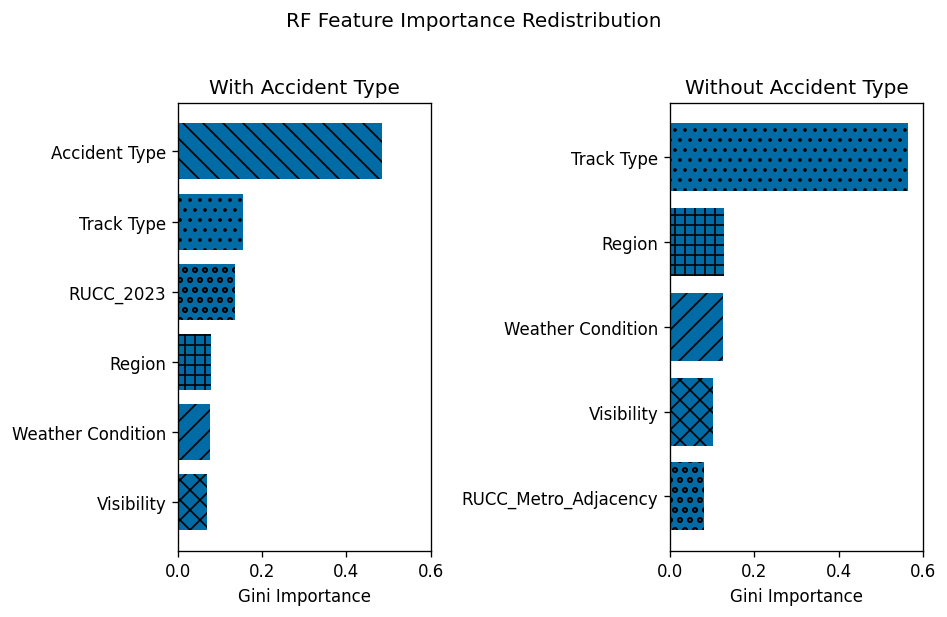

In [22]:
# Side-by-side importance bar chart
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Define consistent hatch per feature
feature_hatches = {
    'Weather Condition': '//',
    'Track Type': '..',
    'Visibility': 'xx',
    'Accident Type': '\\\\',
    'Region': '++',
    'RUCC_Metro_Adjacency': 'oo',
    'RUCC_2023': 'oo'
}

# Left: With Accident Type (baseline)
baseline_imp_df = pd.DataFrame({
    'Feature': baseline_feature_names,
    'Gini Importance': baseline_importances
}).sort_values('Gini Importance', ascending=False)

bars_left = axes[0].barh(baseline_imp_df['Feature'], baseline_imp_df['Gini Importance'])
for bar, feat in zip(bars_left, baseline_imp_df['Feature']):
    bar.set_hatch(feature_hatches.get(feat, ''))
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('With Accident Type')
axes[0].set_xlim(0, 0.6)
axes[0].invert_yaxis()

# Right: Without Accident Type
bars_right = axes[1].barh(importance_df['Feature'], importance_df['Gini Importance'])
for bar, feat in zip(bars_right, importance_df['Feature']):
    bar.set_hatch(feature_hatches.get(feat, ''))
axes[1].set_xlabel('Gini Importance')
axes[1].set_title('Without Accident Type')
axes[1].set_xlim(0, 0.6)
axes[1].invert_yaxis()

fig.suptitle('RF Feature Importance Redistribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Note on RUCC encoding difference:** The side-by-side feature importance chart shows RUCC_2023 (raw, 9 codes) in the baseline and RUCC_Metro_Adjacency (binned, 3 categories) in the updated model. This is not an error. The baseline was built before LR tuning Experiment 3 determined that binned RUCC performed identically to raw RUCC (0.4091 vs 0.4092 F1) and was selected for interpretability. The importance comparison between the two charts reflects two changes simultaneously: Accident Type removal and RUCC rebinning. The RUCC importance drop from 0.130 (baseline) to 0.081 (updated) is partially attributable to the encoding change - 3 bins offer fewer splitting opportunities than 9 codes - and partially to importance redistribution after Accident Type removal.

### Experiment 2 Findings

**What happened:** With Accident Type removed, Track Type absorbed the majority of the freed importance budget, jumping from 0.150 to 0.564. It now accounts for more than half of all split decisions in the forest. The remaining four features share the other 44% in a relatively even spread: Region (0.127), Weather Condition (0.126), Visibility (0.102), and RUCC_Metro_Adjacency (0.081).

**Comparison to Phase 2 statistical rankings:** Cramer's V measures the strength of association between two categorical variables on a 0-to-1 scale, independent of any model. It answers "how strongly is this feature related to Cause Category in the raw data?" Meanwhile, Gini importance answers a different question: "how useful is this feature for making tree splits?" Comparing the two tells us whether the model's learned priorities match the underlying statistical relationships.

**Comparison to Phase 2 statistical rankings:**

| Feature | Cramer's V Rank | Gini Importance (no AT) |
|---|---|---|
| Track Type | 0.21 (1st) | 0.564 (1st) |
| RUCC_Metro_Adjacency | 0.077 (2nd) | 0.081 (5th) |
| Region | 0.05 (3rd) | 0.127 (2nd) |
| Visibility | 0.04 (4th) | 0.102 (4th) |
| Weather Condition | 0.04 (5th) | 0.126 (3rd) |

Track Type leads in both rankings, confirming it is the strongest predictor of cause category among the operational and environmental features. The middle features (Region, Weather, Visibility) shuffled order slightly between the two methods, which is expected since Cramer's V measures statistical association while Gini importance measures usefulness for tree-based splitting. RUCC dropped from 2nd in Cramer's V to 5th in Gini importance, suggesting its 3 bins (Metro, Adjacent, Nonadjacent) provide less splitting value for trees than the finer-grained categories in Region and Weather.

**Interpretation:** The importance distribution is concentrated but not as extreme as the baseline. Accident Type had consumed 0.48 (nearly half). Track Type now takes 0.56, which is even higher proportionally, but the remaining features are more evenly distributed (0.08-0.13) compared to the baseline where everything outside Accident Type was compressed below 0.15. The model is using a broader combination of features for the non-Track-Type splits, which is a healthier pattern for generalization.

---

# Section 2: Hyperparameter Tuning

## Experiment 3: GridSearchCV

**What we are doing:** Systematically searching over RF hyperparameters to find the configuration that maximizes weighted F1 on the 5-feature set (without Accident Type).

**Why we are doing it:** The baseline RF used sklearn defaults (100 trees, no depth limit, class_weight=None). Tree-based models have several hyperparameters that interact with each other, and the optimal configuration depends on the specific dataset. Unlike LR where tuning had virtually no effect, RF has more room for improvement because its hyperparameters control model complexity in fundamentally different ways.

**What each hyperparameter controls:**
- **n_estimators:** Number of trees in the forest. More trees generally improve performance up to a point of diminishing returns, then just slow down training. 100 is sklearn's default; we test whether 200 or 300 helps.
- **max_depth:** Maximum depth of each tree. `None` lets trees grow until all leaves are pure, which risks overfitting. Setting a limit (like 10 or 20) forces simpler trees that may generalize better.
- **min_samples_leaf:** Minimum number of samples required at a leaf node. Higher values (like 5 or 10) prevent the tree from creating leaves for tiny subgroups, which reduces overfitting. Default is 1, meaning a leaf can represent a single training example.
- **max_features:** Number of features considered at each split. `sqrt` (default) considers the square root of total features at each split, adding randomness that decorrelates trees. `log2` considers even fewer, increasing diversity further. `None` considers all features at every split, reducing randomness.
- **class_weight:** How to weight classes during training. `None` treats all classes equally. `balanced` weights inversely proportional to class frequency, giving rare classes (S, E) more influence. LR and RF baselines both showed `balanced` hurting weighted F1, but it's worth retesting with the new feature set.

**What to look for in the results:**
- **Does max_depth help?** If limiting depth improves CV score, the default unlimited trees were overfitting.
- **Does class_weight='balanced' still hurt?** It hurt in every prior experiment, but the feature set has changed.
- **Diminishing returns on n_estimators:** If 200 trees match 100, we're already at the plateau.

In [10]:
# Locked feature set from LR tuning experiments
cat_features_final = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                       'RUCC_Metro_Adjacency']
num_features_final = []

X_final = df_train[cat_features_final + num_features_final].copy()

# Build base pipeline for GridSearch
pipeline_grid = build_rf_pipeline(cat_features_final, num_features_final)

# Define parameter grid
# Strategic grid - test the most impactful hyperparameters without
# combinatorial explosion. 
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': [None, 'balanced']
}

# Count total combinations
n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)

print(f"Parameter combinations: {n_combos}")
print(f"Total fits (5-fold CV): {n_combos * 5}")
print(f"\nThis may take several minutes...\n")

grid_search = GridSearchCV(
    pipeline_grid,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_final, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Parameter combinations: 216
Total fits (5-fold CV): 1080

This may take several minutes...

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}
Best CV score: 0.4213


In [23]:
# Display top 15 results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_display = grid_results[['param_classifier__n_estimators', 
                              'param_classifier__max_depth',
                              'param_classifier__min_samples_leaf',
                              'param_classifier__max_features',
                              'param_classifier__class_weight',
                              'mean_test_score', 'std_test_score', 
                              'rank_test_score']]
grid_display = grid_display.sort_values('rank_test_score')
grid_display.columns = ['Trees', 'Depth', 'Min Leaf', 'Max Feat', 
                          'Weight', 'Mean F1', 'Std F1', 'Rank']

# Clean up NaN display
grid_display['Weight'] = grid_display['Weight'].fillna('None')
grid_display['Depth'] = grid_display['Depth'].fillna('None')
grid_display['Max Feat'] = grid_display['Max Feat'].fillna('all')

print("GridSearchCV Results - Top 15 (sorted by rank):")
print(grid_display.head(15).to_string(index=False))

# Show bottom 3 for contrast
print(f"\nBottom 3:")
print(grid_display.tail(3).to_string(index=False))

print(f"\n{len(grid_display)} total configurations tested.")
print(f"Top-to-bottom F1 range: {grid_display['Mean F1'].max():.4f} to {grid_display['Mean F1'].min():.4f}")

GridSearchCV Results - Top 15 (sorted by rank):
 Trees Depth  Min Leaf Max Feat Weight  Mean F1   Std F1  Rank
   300  None         1     sqrt   None 0.421349 0.006727     1
   300    20         1     sqrt   None 0.421349 0.006727     1
   300    30         1     sqrt   None 0.421349 0.006727     1
   300    30         1     log2   None 0.421349 0.006727     1
   300    20         1     log2   None 0.421349 0.006727     1
   300  None         1     log2   None 0.421349 0.006727     1
   300    10         1      all   None 0.421327 0.005977     7
   300    20         1      all   None 0.421120 0.006419     8
   300  None         1      all   None 0.421120 0.006419     8
   300    30         1      all   None 0.421120 0.006419     8
   100    10         1      all   None 0.421036 0.005739    11
   200    30         1     log2   None 0.421000 0.006070    12
   200    30         1     sqrt   None 0.421000 0.006070    12
   200    20         1     log2   None 0.421000 0.006070    12
   200 

In [24]:
# Run CV with best params for detailed metrics
best_params = grid_search.best_params_
pipeline_best = build_rf_pipeline(
    cat_features_final, num_features_final,
    n_estimators=best_params['classifier__n_estimators'],
    max_depth=best_params['classifier__max_depth'],
    min_samples_leaf=best_params['classifier__min_samples_leaf'],
    max_features=best_params['classifier__max_features'],
    class_weight=best_params['classifier__class_weight']
)

results_exp3 = run_cv_experiment(pipeline_best, X_final, y_train)

print(f"Best GridSearch RF CV: {results_exp3['mean']:.4f} +/- {results_exp3['std']:.4f}")
print(f"\nPer-class metrics:")
print(results_exp3['per_class_metrics'].to_string(index=False))

print(f"\nClassification report:")
print(classification_report(results_exp3['last_y_val'], results_exp3['last_y_pred'], 
                             labels=CAUSE_ORDER, zero_division=0))

Best GridSearch RF CV: 0.4213 +/- 0.0067

Per-class metrics:
Cause  Precision  Recall    F1
    E      0.365   0.039 0.070
    H      0.513   0.774 0.617
    M      0.456   0.568 0.506
    S      0.500   0.007 0.014
    T      0.438   0.154 0.227

Classification report:
              precision    recall  f1-score   support

           E       0.37      0.04      0.07       596
           H       0.51      0.77      0.62      2172
           M       0.46      0.57      0.51      1416
           S       0.50      0.01      0.01       139
           T       0.44      0.15      0.23      1205

    accuracy                           0.49      5528
   macro avg       0.45      0.31      0.29      5528
weighted avg       0.47      0.49      0.43      5528



In [13]:
# Save results
save_experiment(
    results_exp3,
    features={'categorical': cat_features_final, 'numeric': num_features_final},
    experiment_name='RF GridSearchCV (5 features, no Accident Type)',
    filepath='../results/rf/rf_tuned_gridsearch.json',
    best_params={k.replace('classifier__', ''): str(v) for k, v in best_params.items()},
    n_configurations_tested=n_combos
)

Saved: ../results/rf/rf_tuned_gridsearch.json


Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
Baseline (6 feat, w/ AT)                0.5507     0.0083        6
No Accident Type (5 feat)               0.4210     0.0053        5
GridSearch Tuned (5 feat)               0.4213     0.0067        5


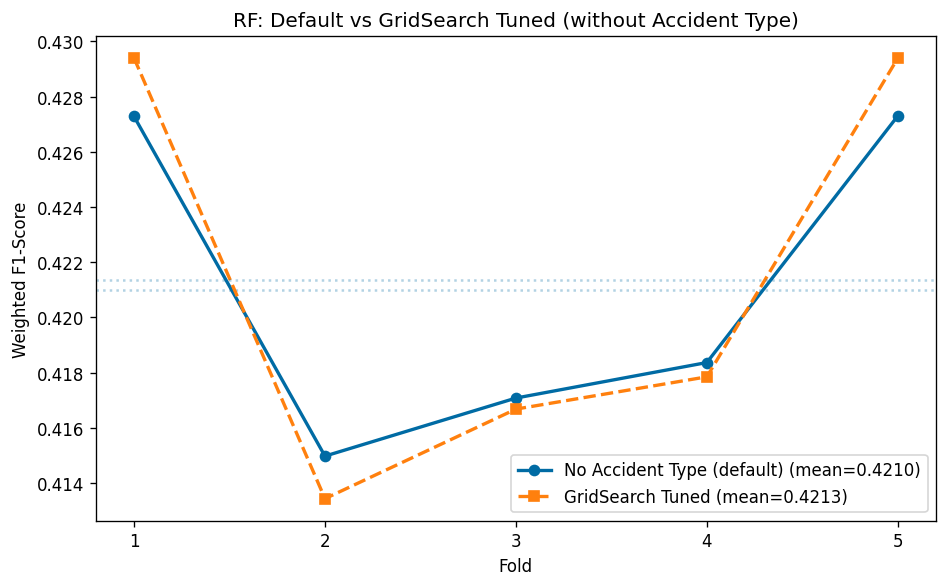

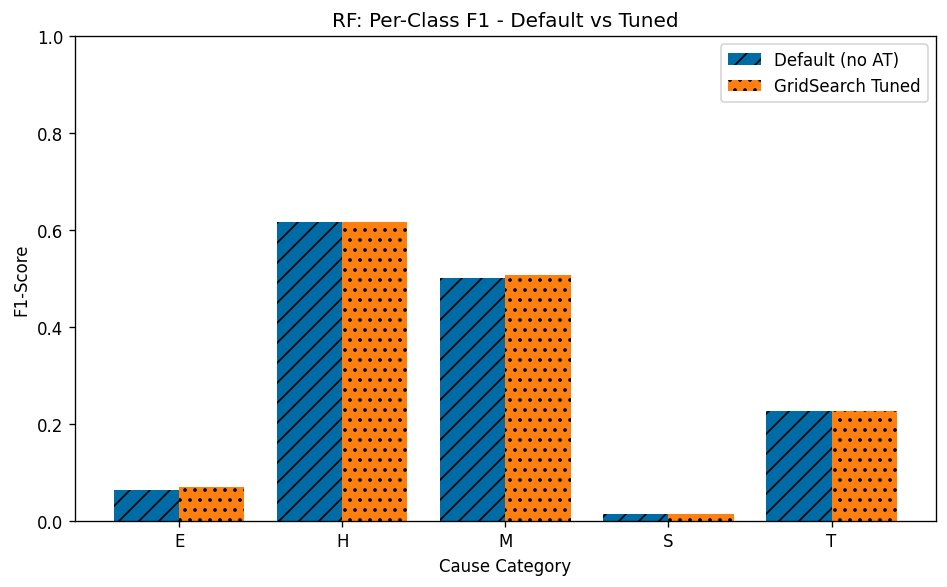

In [14]:
# Compare all RF experiments
compare_experiments(
    names=['Baseline (6 feat, w/ AT)', 'No Accident Type (5 feat)', 'GridSearch Tuned (5 feat)'],
    filepaths=[
        '../results/rf/rf_baseline_results.json',
        '../results/rf/rf_exp_no_accident_type.json',
        '../results/rf/rf_tuned_gridsearch.json'
    ]
)

# CV score comparison plot
plot_cv_comparison(
    experiments=[
        ('No Accident Type (default)', results_exp1['scores']),
        ('GridSearch Tuned', results_exp3['scores'])
    ],
    title='RF: Default vs GridSearch Tuned (without Accident Type)'
)

# Per-class comparison
plot_per_class_comparison(
    [results_exp1['per_class_metrics'], results_exp3['per_class_metrics']],
    ['Default (no AT)', 'GridSearch Tuned'],
    title='RF: Per-Class F1 - Default vs Tuned'
)

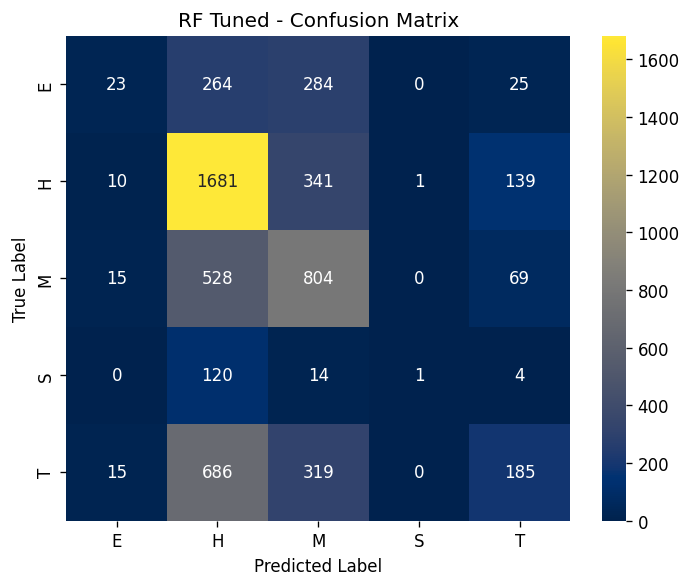

In [15]:
# Confusion matrix for best model
cm = confusion_matrix(results_exp3['last_y_val'], results_exp3['last_y_pred'], 
                       labels=CAUSE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
ax.set_title('RF Tuned - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Experiment 3 Findings

**What this tested:** We searched 216 hyperparameter combinations across tree count, depth limits, leaf size, feature sampling, and class weighting to determine if any configuration could improve RF beyond its default settings on the 5-feature set.

**Best hyperparameters:** 300 trees, no depth limit, min_samples_leaf=1, max_features='sqrt', no class weighting. This is essentially sklearn's default configuration with more trees.

**Did tuning help?** No. Best GridSearch score was 0.4213, compared to 0.4210 from the default 100-tree model in Experiment 1. A 0.0003 improvement is well within noise. The top-to-bottom range across all 216 configurations shows how little room there is to move.

**Key observations:**

- **max_depth:** No depth limit, depth=20, and depth=30 all tied in the top results. With only 5 features, trees are shallow by nature and cannot overfit. There is not enough feature space to build deep, complex trees that would benefit from pruning.

- **class_weight='balanced':** Did not appear in the top 15 configurations, consistent with every prior experiment across LR and RF. On this dataset, weighting minority classes forces the model to make predictions it cannot support with 5 features, degrading overall weighted F1.

- **n_estimators:** 300 trees slightly edged 200 and 100 in the rankings, but the differences are in the 4th decimal place. The forest is already at the plateau where additional trees add computation time without improving accuracy.

- **max_features:** 'sqrt' and 'log2' tied. With 5 features, sqrt(5) and log2(5) both round to 2 features per split, making them functionally identical.

**Per-class metrics:** Unchanged from every prior configuration. Zero effective predictions for Signal and Environmental, strong Human Factor recall (0.77), moderate Mechanical (0.57), and weak Track (0.15). No hyperparameter combination altered this pattern.

**Takeaway:** Same conclusion as LR tuning - the 0.42 F1 ceiling is a feature limitation, not a model or hyperparameter limitation. RF's nonlinear splits provide a marginal edge over LR (0.421 vs 0.409), but 216 hyperparameter configurations could not push past the fundamental constraint of 5 categorical features with limited discriminative power for minority classes.

---

## Save Best Model

Refit the best RF configuration on the full 80% training set and save for final evaluation.

In [25]:
# Refit best pipeline on full training data
pipeline_best.fit(X_final, y_train)

# Save pipeline
joblib.dump(pipeline_best, '../models/rf_tuned_pipeline.pkl')
print(f"Saved: ../models/rf_tuned_pipeline.pkl")

# Print final feature importance from best model
importances_tuned = pipeline_best.named_steps['classifier'].feature_importances_
importance_tuned_df = pd.DataFrame({
    'Feature': cat_features_final,
    'Gini Importance': importances_tuned
}).sort_values('Gini Importance', ascending=False)

print(f"\nFeature importance (tuned model):")
print(importance_tuned_df.to_string(index=False))

Saved: ../models/rf_tuned_pipeline.pkl

Feature importance (tuned model):
             Feature  Gini Importance
          Track Type         0.561792
   Weather Condition         0.129944
              Region         0.123924
          Visibility         0.103072
RUCC_Metro_Adjacency         0.081267


---

## Final Summary

In [17]:
# Load and compare all RF experiments
import os

rf_results_dir = '../results/rf/'
all_files = sorted([f for f in os.listdir(rf_results_dir) if f.endswith('.json')])

print("=" * 75)
print(f"{'Experiment':<45} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
print("-" * 75)

for f in all_files:
    filepath = os.path.join(rf_results_dir, f)
    with open(filepath, 'r') as fh:
        data = json.load(fh)
    
    name = data.get('experiment', f.replace('.json', ''))
    mean = data.get('cv_mean', data.get('best_cv_mean', 0))
    std = data.get('cv_std', data.get('best_cv_std', 0))
    
    if isinstance(data.get('features'), dict):
        n_feat = data['features']['total']
    elif isinstance(data.get('features'), list):
        n_feat = len(data['features'])
    else:
        n_feat = '?'
    
    print(f"{name:<45} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")

print("=" * 75)

Experiment                                       CV Mean     CV Std Features
---------------------------------------------------------------------------
rf_baseline_results                               0.5507     0.0083        6
RF Baseline without Accident Type                 0.4210     0.0053        5
RF GridSearchCV (5 features, no Accident Type)     0.4213     0.0067        5


## Conclusions

This notebook validated the Accident Type removal decision on RF and optimized hyperparameters across 216 configurations. Three experiments confirmed that the 0.42 F1 ceiling is driven by the feature set, not the model.

**Best RF configuration:** 300 trees, no depth limit, min_samples_leaf=1, max_features='sqrt', no class weighting, 5 features (Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency). This is functionally identical to sklearn defaults with additional trees.

**Key findings:**

1. **Removing Accident Type dropped RF by 0.130 (0.551 to 0.421), nearly identical to LR's 0.127 drop.** This confirms Accident Type dominance is a data-level problem. Both linear and nonlinear algorithms lose the same amount of predictive power when the confounding variable is removed, meaning neither can compensate through model complexity alone.

2. **Track Type absorbed the majority of Accident Type's importance budget, jumping from 0.150 to 0.564.** The remaining four features distributed fairly evenly (0.08 to 0.13). The Gini importance ranking largely matched Phase 2 Cramer's V rankings, with Track Type leading both. RUCC_Metro_Adjacency dropped from 2nd in Cramer's V to 5th in Gini importance, suggesting its 3-bin encoding provides less splitting value for trees than finer-grained categorical features.

3. **GridSearchCV produced no meaningful improvement.** Best tuned score (0.4213) beat the default (0.4210) by 0.0003. Depth limiting had no effect because 5 features produce naturally shallow trees. Class weighting hurt performance again. Feature sampling options (sqrt vs log2) were functionally identical at this feature count.

4. **RF edges LR by about 0.01 F1 (0.421 vs 0.409) on the same 5 features.** RF's nonlinear splits find small pockets of signal in rare classes that LR cannot detect (Signal and Environmental show nonzero precision in RF, zero in LR). However, the practical difference is minimal. Algorithm choice matters far less than feature selection on this dataset.

**Final tuned model saved to:** `../models/rf_tuned_pipeline.pkl`
**All experiment results saved to:** `../results/rf/`